In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline
sns.set()

In [17]:
df = pd.read_csv(r"D:\data analysis\Projects\Smart Customer Segmentation & Anomaly Detection\CC GENERAL.csv")

In [18]:
df.sample(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5176,C15321,3497.200665,1.0,1350.13,519.80,830.33,1938.008846,0.666667,0.416667,0.583333,0.166667,3,32,4000.0,1882.437447,1279.813588,0.0,12
4319,C14439,2608.512452,1.0,64.20,64.20,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,3000.0,647.437157,957.631664,0.0,12
5868,C16033,2092.156291,1.0,1372.81,1372.81,0.00,0.000000,0.416667,0.416667,0.000000,0.000000,0,16,2250.0,1073.317848,1140.180264,0.0,12
4738,C14867,996.223227,1.0,0.00,0.00,0.00,1398.395540,0.000000,0.000000,0.000000,0.083333,1,0,8000.0,2369.167737,226.016919,0.0,12
6609,C16792,1356.050482,1.0,65.82,39.90,25.92,0.000000,1.000000,0.166667,1.000000,0.000000,0,14,4000.0,493.729322,390.037637,0.0,12


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [20]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


<Axes: >

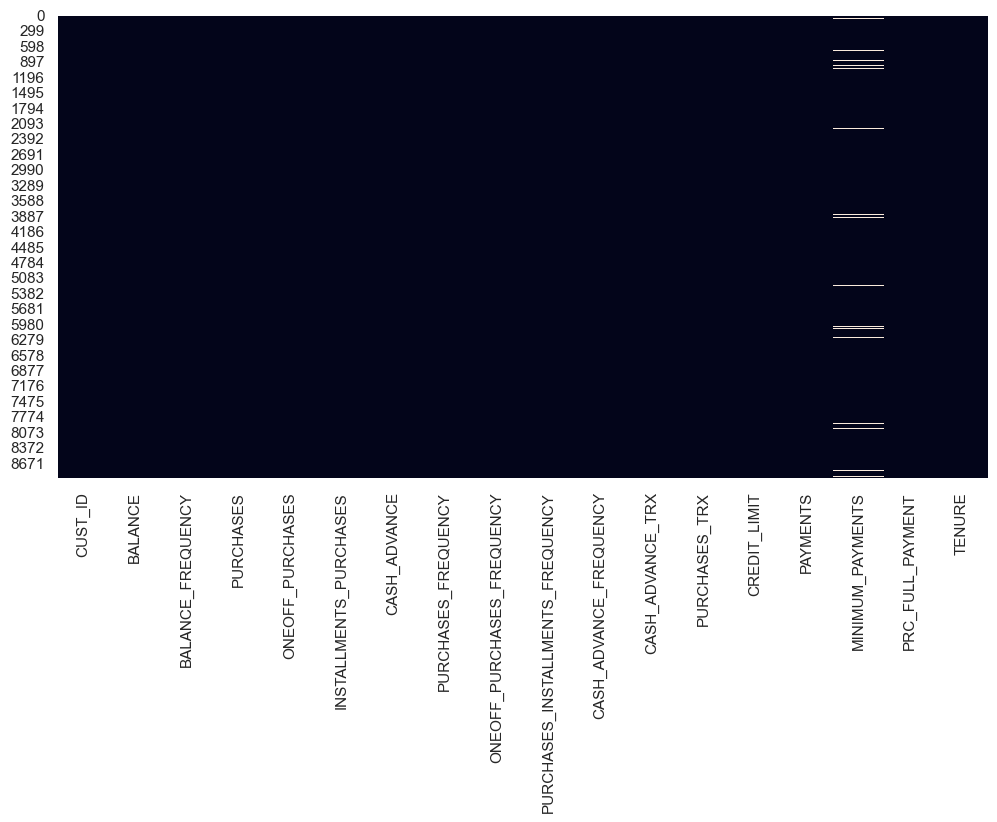

In [21]:
## check missing data 
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)

In [22]:
round(df.isna().sum() * 100/len(df), 2)

CUST_ID                             0.00
BALANCE                             0.00
BALANCE_FREQUENCY                   0.00
PURCHASES                           0.00
ONEOFF_PURCHASES                    0.00
INSTALLMENTS_PURCHASES              0.00
CASH_ADVANCE                        0.00
PURCHASES_FREQUENCY                 0.00
ONEOFF_PURCHASES_FREQUENCY          0.00
PURCHASES_INSTALLMENTS_FREQUENCY    0.00
CASH_ADVANCE_FREQUENCY              0.00
CASH_ADVANCE_TRX                    0.00
PURCHASES_TRX                       0.00
CREDIT_LIMIT                        0.01
PAYMENTS                            0.00
MINIMUM_PAYMENTS                    3.50
PRC_FULL_PAYMENT                    0.00
TENURE                              0.00
dtype: float64

In [23]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [25]:
df['MINIMUM_PAYMENTS'] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [26]:
round(df.isna().sum() * 100/len(df), 2)

CUST_ID                             0.0
BALANCE                             0.0
BALANCE_FREQUENCY                   0.0
PURCHASES                           0.0
ONEOFF_PURCHASES                    0.0
INSTALLMENTS_PURCHASES              0.0
CASH_ADVANCE                        0.0
PURCHASES_FREQUENCY                 0.0
ONEOFF_PURCHASES_FREQUENCY          0.0
PURCHASES_INSTALLMENTS_FREQUENCY    0.0
CASH_ADVANCE_FREQUENCY              0.0
CASH_ADVANCE_TRX                    0.0
PURCHASES_TRX                       0.0
CREDIT_LIMIT                        0.0
PAYMENTS                            0.0
MINIMUM_PAYMENTS                    0.0
PRC_FULL_PAYMENT                    0.0
TENURE                              0.0
dtype: float64

In [27]:
#chekc duplicated
df.duplicated().sum()

np.int64(0)

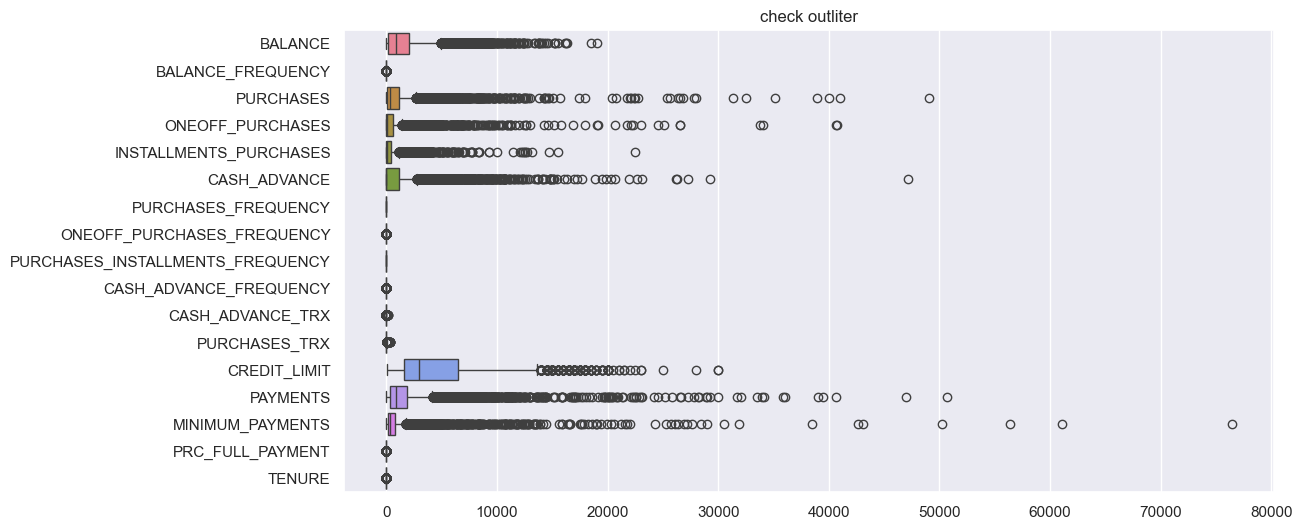

In [33]:
plt.figure(figsize=(12,6))
sns.boxplot(data = df, orient="h")
plt.title("check outliter")
plt.show()

In [34]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

BALANCE: 695 outliers
BALANCE_FREQUENCY: 1493 outliers
PURCHASES: 808 outliers
ONEOFF_PURCHASES: 1013 outliers
INSTALLMENTS_PURCHASES: 867 outliers
CASH_ADVANCE: 1030 outliers
PURCHASES_FREQUENCY: 0 outliers
ONEOFF_PURCHASES_FREQUENCY: 782 outliers
PURCHASES_INSTALLMENTS_FREQUENCY: 0 outliers
CASH_ADVANCE_FREQUENCY: 525 outliers
CASH_ADVANCE_TRX: 804 outliers
PURCHASES_TRX: 766 outliers
CREDIT_LIMIT: 248 outliers
PAYMENTS: 808 outliers
MINIMUM_PAYMENTS: 907 outliers
PRC_FULL_PAYMENT: 1474 outliers
TENURE: 1366 outliers


In [35]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower, upper=upper)

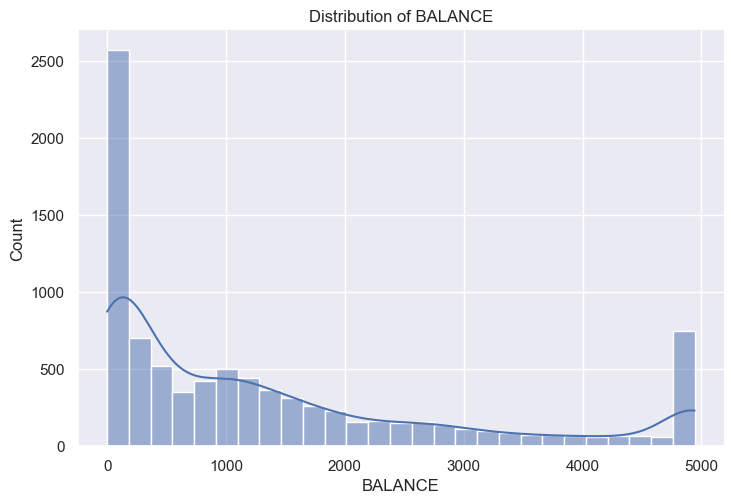

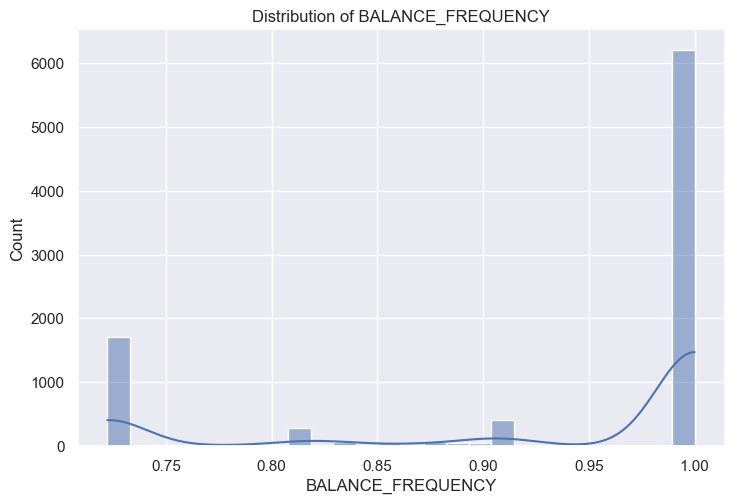

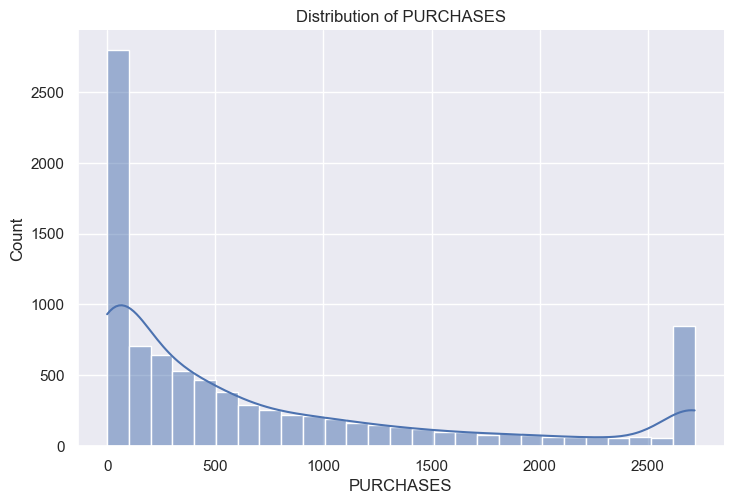

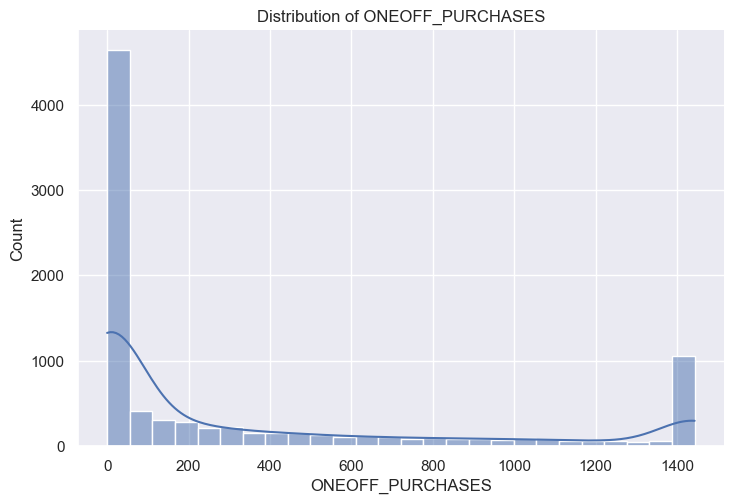

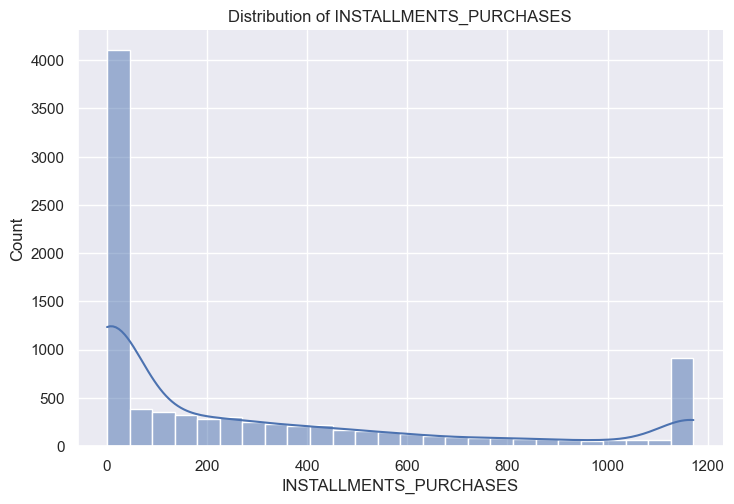

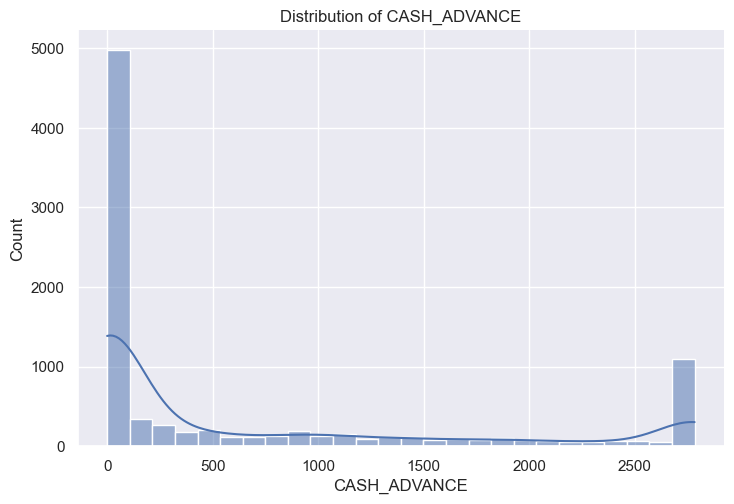

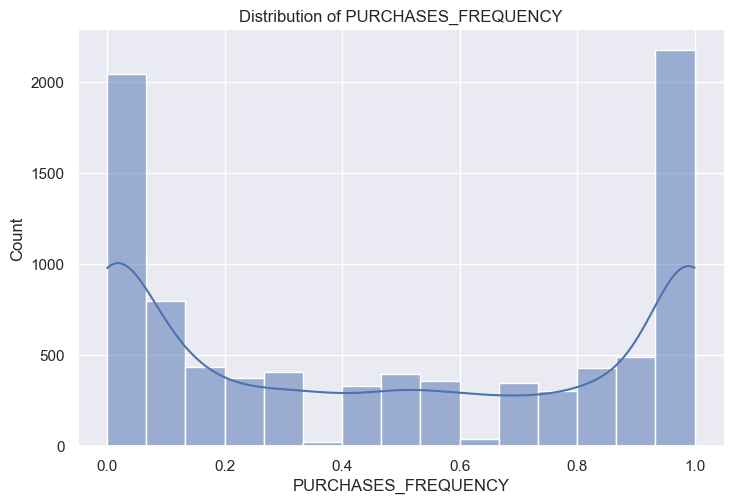

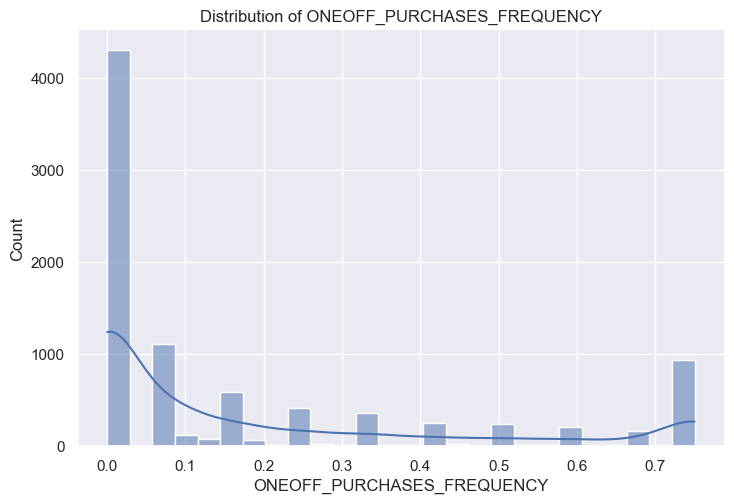

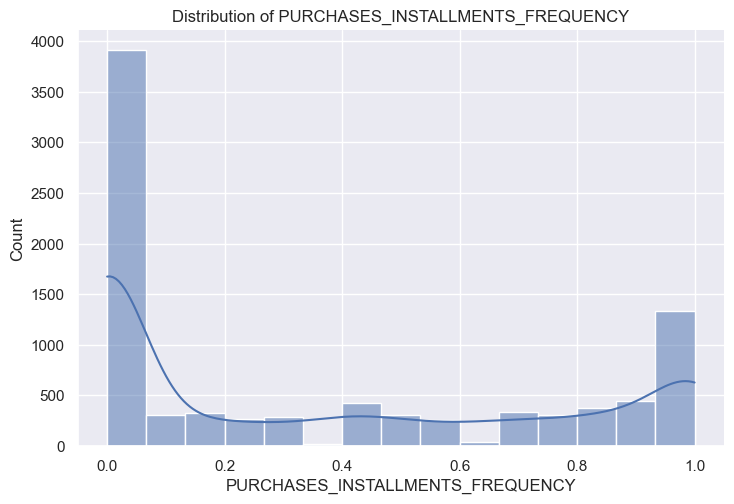

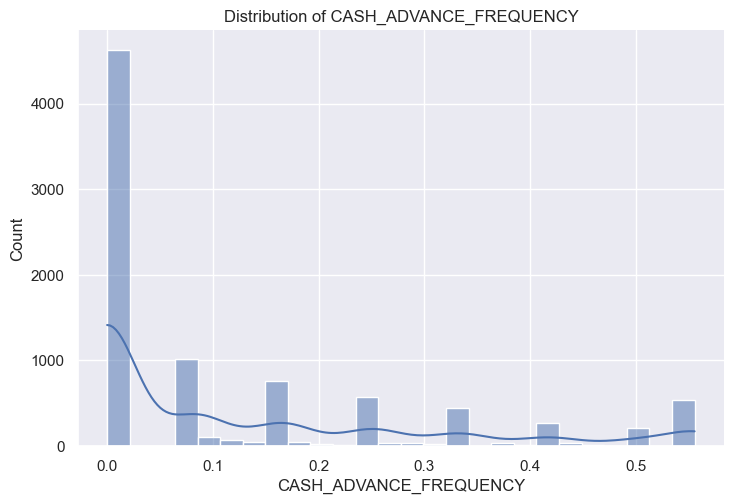

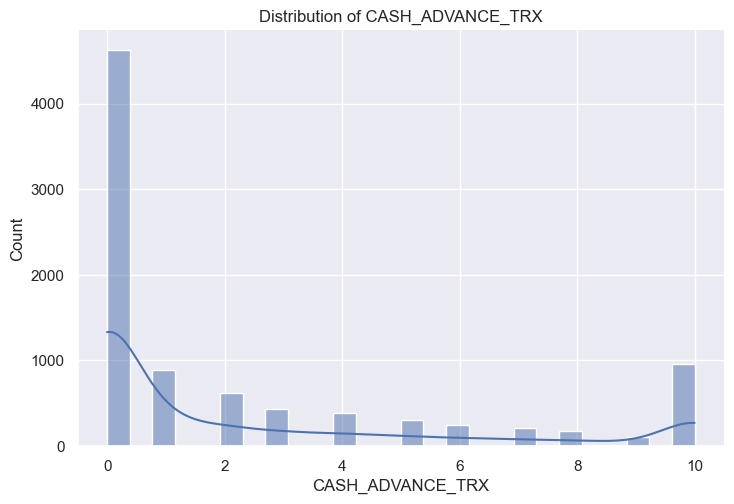

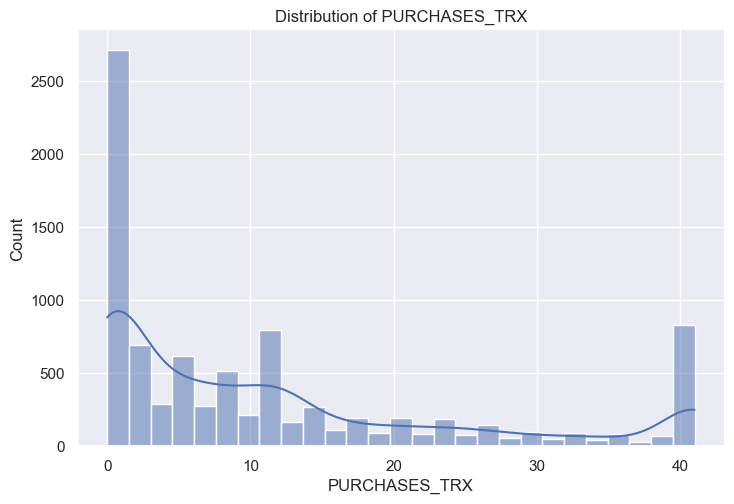

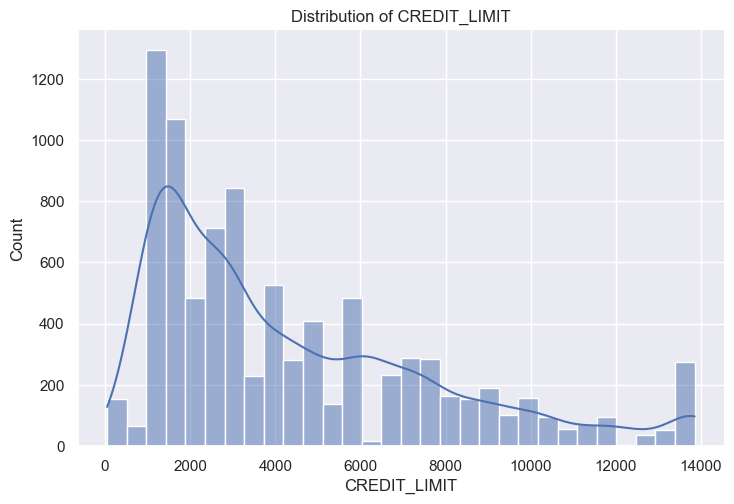

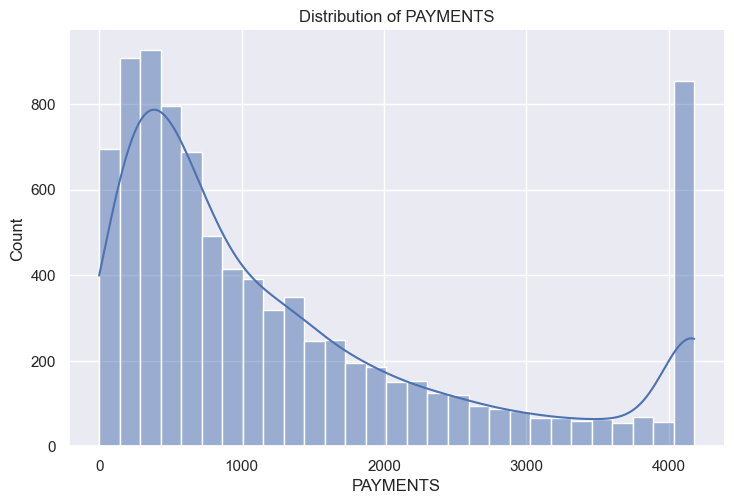

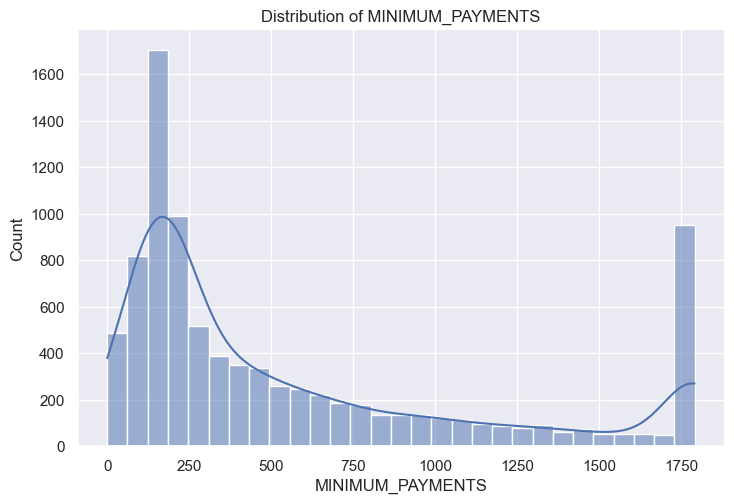

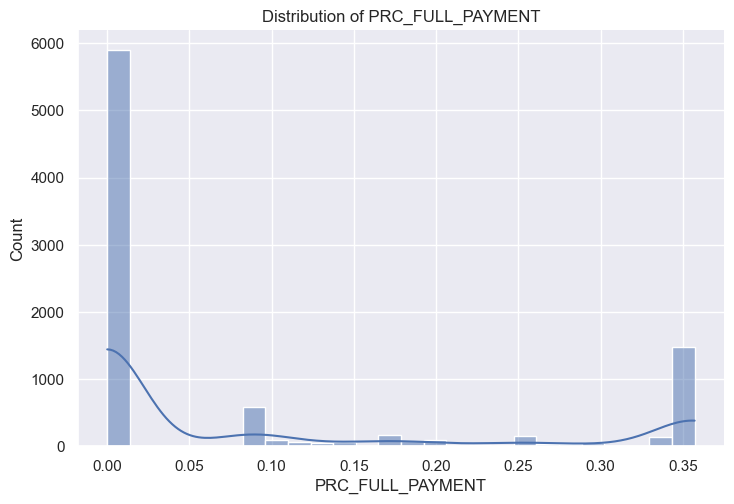

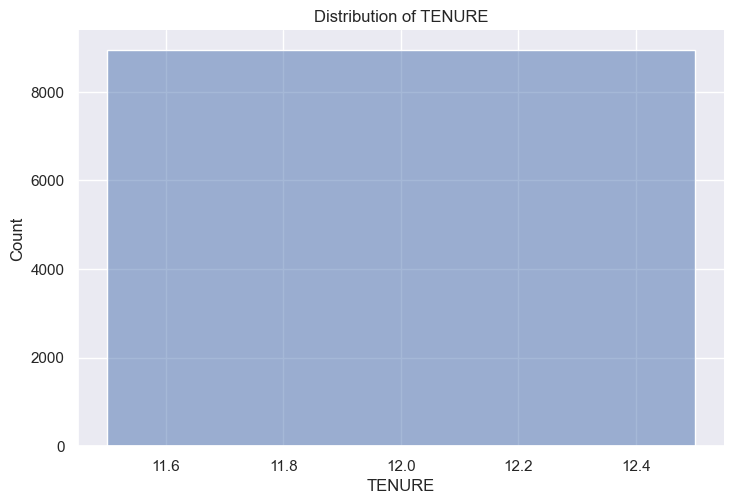

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    sns.displot(
        data=df,
        x=col,
        kde=True,
        height=5,
        aspect=1.5
    )
    plt.title(f"Distribution of {col}")
    plt.show()

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [60]:
df.to_csv("data_cleaned.csv", index=False)

### Feature selection

In [43]:
import pandas as pd
import numpy as np

# Remove customer ID
df_model = df.drop(columns=["CUST_ID"])

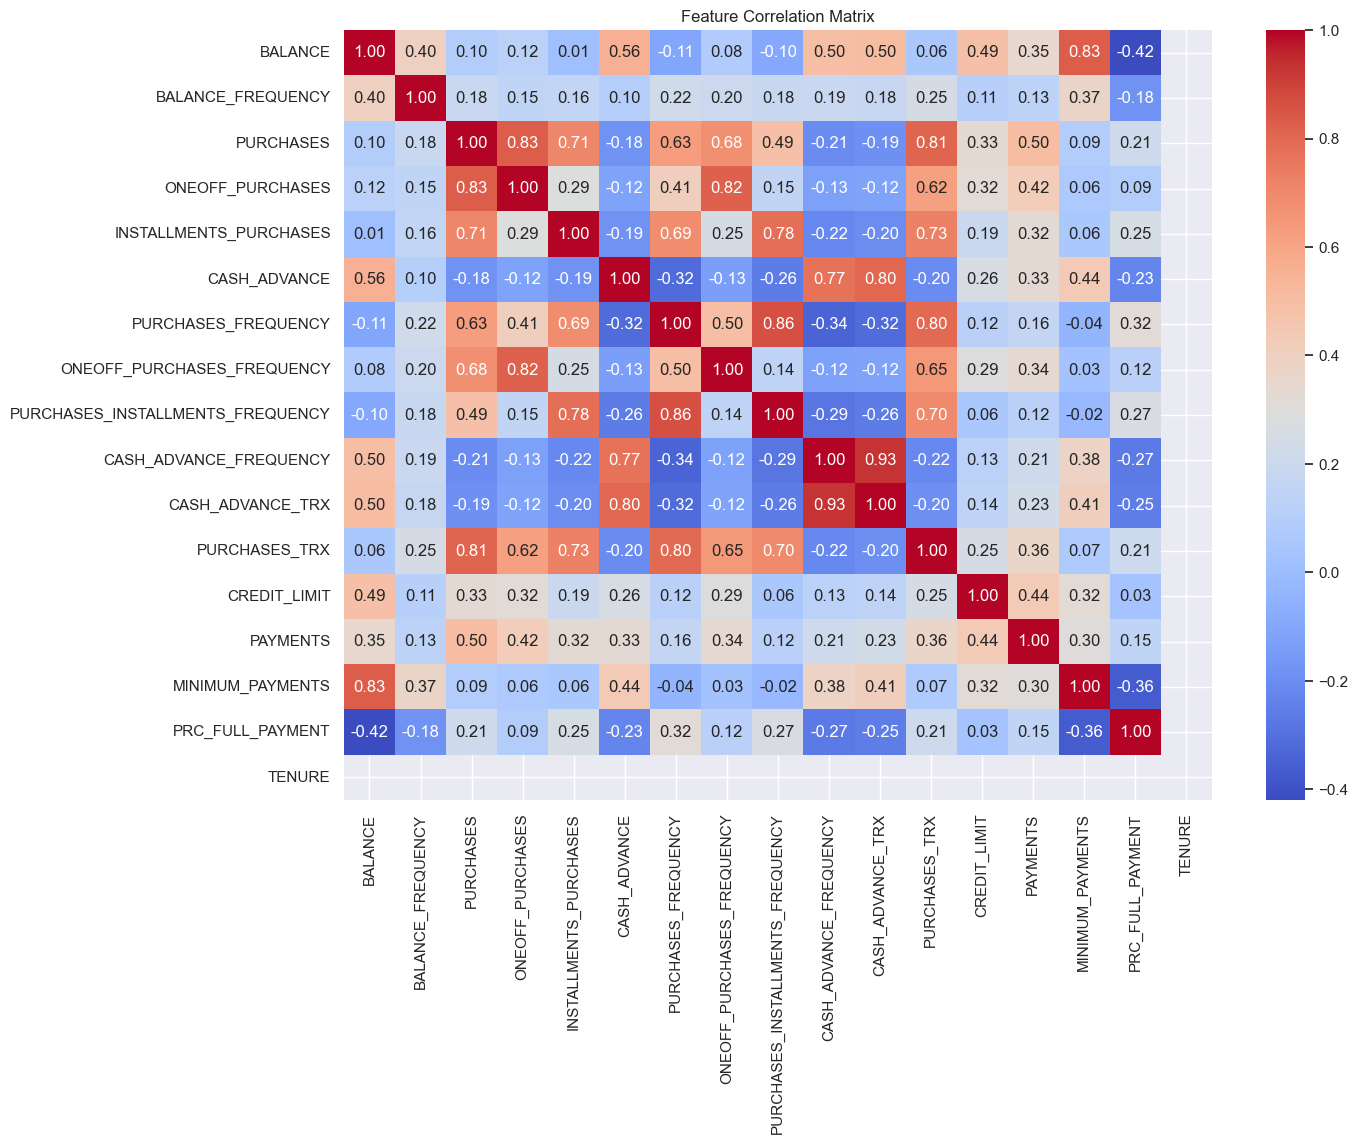

In [44]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_model.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [46]:
# Credit utilization
df_model["CREDIT_UTILIZATION"] = (
    df_model["BALANCE"] /
    df_model["CREDIT_LIMIT"].replace(0, np.nan)
)

# Average purchase amount
df_model["AVG_PURCHASE_AMOUNT"] = (
    df_model["PURCHASES"] /
    df_model["PURCHASES_TRX"].replace(0, np.nan)
)

# Average cash advance amount
df_model["AVG_CASH_ADVANCE"] = (
    df_model["CASH_ADVANCE"] /
    df_model["CASH_ADVANCE_TRX"].replace(0, np.nan)
)

# Payment ratio
df_model["PAYMENT_RATIO"] = (
    df_model["PAYMENTS"] /
    df_model["BALANCE"].replace(0, np.nan)
)


In [47]:

# ============================================================
# STEP 6 — Handle Infinite & New Missing Values
# ============================================================

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

df_model.fillna(0, inplace=True)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,AVG_PURCHASE_AMOUNT,AVG_CASH_ADVANCE,PAYMENT_RATIO
0,40.900749,0.818182,95.40,0.0000,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,...,2,1000.0,201.802084,139.509787,0.000000,12,0.040901,47.700000,0.000000,4.933946
1,3202.467416,0.909091,0.00,0.0000,0.00,2784.552848,0.000000,0.000000,0.000000,0.250000,...,0,7000.0,4103.032597,1072.340217,0.222222,12,0.457495,0.000000,696.138212,1.281210
2,2495.148862,1.000000,773.17,773.1700,0.00,0.000000,1.000000,0.750000,0.000000,0.000000,...,12,7500.0,622.066742,627.284787,0.000000,12,0.332687,64.430833,0.000000,0.249310
3,1666.670542,0.722223,1499.00,1443.5125,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,...,1,7500.0,0.000000,1790.762415,0.000000,12,0.222223,1499.000000,205.788017,0.000000
4,817.714335,1.000000,16.00,16.0000,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,...,1,1200.0,678.334763,244.791237,0.000000,12,0.681429,16.000000,0.000000,0.829550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.0000,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,...,6,1000.0,325.594462,48.886365,0.357143,12,0.028494,48.520000,0.000000,11.426966
8946,19.183215,1.000000,300.00,0.0000,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,...,6,1000.0,275.861322,45.726120,0.000000,12,0.019183,50.000000,0.000000,14.380349
8947,23.398673,0.833333,144.40,0.0000,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,...,5,1000.0,81.270775,82.418369,0.250000,12,0.023399,28.880000,0.000000,3.473307
8948,13.457564,0.833333,0.00,0.0000,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,...,0,500.0,52.549959,55.755628,0.250000,12,0.026915,0.000000,18.279389,3.904864


In [48]:
features = [
    "BALANCE",
    "CREDIT_UTILIZATION",

    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",

    "CASH_ADVANCE",
    "CASH_ADVANCE_FREQUENCY",
    "CASH_ADVANCE_TRX",

    "PAYMENTS",
    "PAYMENT_RATIO",

    "PRC_FULL_PAYMENT",
    "TENURE"
]

X = df_model[features].copy()

In [49]:

print("\nSkewness:")
print(X.skew().sort_values(ascending=False))



Skewness:
PAYMENT_RATIO             90.317043
CREDIT_UTILIZATION         8.094735
CASH_ADVANCE_TRX           1.282306
CASH_ADVANCE_FREQUENCY     1.273882
CASH_ADVANCE               1.241773
PRC_FULL_PAYMENT           1.211291
PURCHASES                  1.206380
BALANCE                    1.166703
PURCHASES_TRX              1.139781
PAYMENTS                   1.130056
PURCHASES_FREQUENCY        0.060164
TENURE                     0.000000
dtype: float64


In [50]:
skewed_features = [
    "BALANCE",
    "PURCHASES",
    "PURCHASES_TRX",
    "CASH_ADVANCE",
    "CASH_ADVANCE_TRX",
    "PAYMENTS"
]

for col in skewed_features:
    X[col] = np.log1p(X[col])



In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
print("\nFinal dataset shape:")
print(X_scaled.shape)

print("\nMissing values:")
print(np.isnan(X_scaled).sum())

print("\nMean of scaled features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation:")
print(X_scaled.std(axis=0))




Final dataset shape:
(8950, 12)

Missing values:
0

Mean of scaled features:
[ 4.06478079e-16 -5.71609799e-17 -6.98634198e-17 -1.84185380e-16
  8.25658598e-17 -6.35121998e-17  5.23975649e-17 -2.22292699e-17
  6.35121998e-17  7.14512248e-18 -9.20926898e-17  0.00000000e+00]

Standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]


In [53]:
print(df_model["TENURE"].value_counts())

TENURE
12    8950
Name: count, dtype: int64


In [54]:
print(X["TENURE"].value_counts())

TENURE
12    8950
Name: count, dtype: int64


In [55]:
X.drop("TENURE", axis=1, inplace=True)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [57]:
print("Shape:", X_scaled.shape)
print("Missing values:", np.isnan(X_scaled).sum())
print("Standard deviation:", X_scaled.std(axis=0))

Shape: (8950, 11)
Missing values: 0
Standard deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [59]:
# Convert scaled data to DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Save to CSV
X_scaled_df.to_csv("data_model.csv", index=False)
